# Ejercicio 6 - Parquet versus tablas DuckDB

## Configuracion

In [1]:
import os
import statistics
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
COLORES = {"parquet": "#4C72B0", "tabla": "#DD8452"}

# Base de datos DuckDB del ejercicio. Se recrea en cada ejecucion para que el
# benchmark sea reproducible (los Parquet de data/raw no se tocan).
BASE = Path("data/processed/taxis.duckdb")
BASE.parent.mkdir(parents=True, exist_ok=True)
for archivo in [BASE, BASE.with_suffix(".duckdb.wal")]:
    archivo.unlink(missing_ok=True)
con = duckdb.connect(str(BASE))
# El contenedor tiene 8 GB y tambien corre JupyterLab: se limita la memoria de DuckDB
# (lo que no cabe se escribe a disco) y no se exige conservar el orden de insercion,
# lo que reduce mucho la memoria al crear las tablas.
con.sql("SET memory_limit = '4GB'")
con.sql("SET preserve_insertion_order = false")

REPETICIONES = 5   # ejecuciones medidas por consulta (ademas de una primera ejecucion de calentamiento)

print("DuckDB", con.sql("SELECT version()").fetchone()[0],
      "| hilos:", con.sql("SELECT current_setting('threads')").fetchone()[0],
      "| memoria maxima:", con.sql("SELECT current_setting('memory_limit')").fetchone()[0])

DuckDB v1.5.5 | hilos: 10 | memoria maxima: 3.7 GiB


## Escenarios de tamanio

In [2]:
ESCENARIOS = {
    "1 mes (ene 2026)": ["data/raw/yellow/2026/yellow_tripdata_2026-01.parquet",
                         "data/raw/green/2026/green_tripdata_2026-01.parquet"],
    "8 meses (2026)":   ["data/raw/*/2026/*.parquet"],
    "20 meses (2024 y 2026)": ["data/raw/*/*/*.parquet"],
}
NOMBRE_CORTO = {"1 mes (ene 2026)": "1mes", "8 meses (2026)": "2026", "20 meses (2024 y 2026)": "todo"}


def lista_sql(rutas):
    return "[" + ", ".join(f"'{r}'" for r in rutas) + "]"


filas = []
for escenario, rutas in ESCENARIOS.items():
    archivos = con.sql(f"SELECT file FROM glob({lista_sql(rutas)})").df().file
    filas.append({"escenario": escenario, "archivos": len(archivos),
                  "mb_parquet": sum(Path(a).stat().st_size for a in archivos) / 1e6})
tamanios = pd.DataFrame(filas).set_index("escenario")
tamanios

,archivos,mb_parquet
escenario,,
1 mes (ene 2026),2,65.157
8 meses (2026),16,519.727
20 meses (2024 y 2026),40,"1,228.649"


## 6.1 Vistas sobre los archivos Parquet

In [3]:
SELECT_NORMALIZADO = r'''
SELECT
    split_part(filename, '/', 3)                                        AS tipo,
    split_part(filename, '/', 4)::INT                                   AS anio,
    VendorID                                                            AS vendor_id,
    coalesce(tpep_pickup_datetime,  lpep_pickup_datetime)               AS pickup,
    coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)              AS dropoff,
    date_diff('second', coalesce(tpep_pickup_datetime,  lpep_pickup_datetime),
                        coalesce(tpep_dropoff_datetime, lpep_dropoff_datetime)) / 60.0 AS duracion_min,
    passenger_count, trip_distance,
    RatecodeID AS ratecode_id, PULocationID AS pu_zona, DOLocationID AS do_zona,
    payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount,
    improvement_surcharge, congestion_surcharge, cbd_congestion_fee,
    Airport_fee AS airport_fee, total_amount, trip_type
FROM read_parquet({rutas}, filename = true, union_by_name = true)
'''

for escenario, rutas in ESCENARIOS.items():
    con.sql(f"CREATE OR REPLACE VIEW pq_{NOMBRE_CORTO[escenario]} AS "
            + SELECT_NORMALIZADO.format(rutas=lista_sql(rutas)))

con.sql('''
CREATE OR REPLACE TABLE zonas AS
SELECT LocationID AS zona, Borough AS borough, Zone AS nombre_zona
FROM read_csv('https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv')
''')
con.sql("SELECT table_name, table_type FROM information_schema.tables ORDER BY table_name").df()

,table_name,table_type
0,pq_1mes,VIEW
1,pq_2026,VIEW
2,pq_todo,VIEW
3,zonas,BASE TABLE


## 6.2 Creacion de las tablas materializadas

In [4]:
filas = []
for escenario in ESCENARIOS:
    corto = NOMBRE_CORTO[escenario]
    con.sql("CHECKPOINT")
    antes = BASE.stat().st_size
    inicio = time.perf_counter()
    con.sql(f"CREATE OR REPLACE TABLE tb_{corto} AS SELECT * FROM pq_{corto}")
    con.sql("CHECKPOINT")
    segundos = time.perf_counter() - inicio
    filas.append({"escenario": escenario,
                  "tabla": f"tb_{corto}",
                  "registros": con.sql(f"SELECT count(*) FROM tb_{corto}").fetchone()[0],
                  "segundos_carga": segundos,
                  "mb_tabla": (BASE.stat().st_size - antes) / 1e6})

carga = pd.DataFrame(filas).set_index("escenario").join(tamanios)
carga["tabla / parquet"] = carga["mb_tabla"] / carga["mb_parquet"]
display(carga)
print(f"Tamanio total de {BASE}: {BASE.stat().st_size / 1e9:.2f} GB")

,tabla,registros,segundos_carga,mb_tabla,archivos,mb_parquet,tabla / parquet
escenario,,,,,,,
1 mes (ene 2026),tb_1mes,3765161,1.188,132.645,2,65.157,2.036
8 meses (2026),tb_2026,30040469,4.949,"1,076.101",16,519.727,2.071
20 meses (2024 y 2026),tb_todo,71870407,9.730,"2,563.506",40,"1,228.649",2.086


Tamanio total de data/processed/taxis.duckdb: 3.77 GB


## 6.3 Consultas representativas

In [5]:
CONSULTAS = {
    "C1 conteo por tipo": '''
        SELECT tipo, count(*) AS viajes
        FROM {fuente}
        GROUP BY tipo''',
    "C2 viajes por mes": '''
        SELECT tipo, date_trunc('month', pickup) AS mes, count(*) AS viajes,
               avg(total_amount) AS total_promedio
        FROM {fuente}
        GROUP BY tipo, mes''',
    "C3 hora y dia de la semana": '''
        SELECT tipo, isodow(pickup) AS dia, hour(pickup) AS hora, count(*) AS viajes
        FROM {fuente}
        GROUP BY tipo, dia, hora''',
    # Las medianas exactas guardan todos los valores en memoria (no pueden escribirse a
    # disco); con 4 medianas sobre 72 M de filas el contenedor de 8 GB se queda sin memoria.
    "C4 medianas por tipo": '''
        SELECT tipo,
               median(trip_distance)                      AS distancia_mediana,
               median(total_amount)                       AS total_mediano
        FROM {fuente}
        WHERE duracion_min BETWEEN 1 AND 180 AND trip_distance > 0
        GROUP BY tipo''',
    "C5 propina por hora (tarjeta)": '''
        SELECT tipo, hour(pickup) AS hora,
               avg(tip_amount / fare_amount) AS propina_pct_promedio
        FROM {fuente}
        WHERE payment_type = 1 AND fare_amount > 0
        GROUP BY tipo, hora''',
    "C6 top zonas (join)": '''
        SELECT z.borough, z.nombre_zona, count(*) AS viajes
        FROM {fuente} v
        JOIN zonas z ON v.pu_zona = z.zona
        GROUP BY z.borough, z.nombre_zona
        ORDER BY viajes DESC, z.nombre_zona
        LIMIT 10''',
    "C7 filtro de un dia": '''
        SELECT tipo, count(*) AS viajes, avg(total_amount) AS total_promedio
        FROM {fuente}
        WHERE pickup >= TIMESTAMP '2026-01-15' AND pickup < TIMESTAMP '2026-01-16'
        GROUP BY tipo''',
    "C8 pares origen-destino distintos": '''
        SELECT tipo, count(DISTINCT (pu_zona, do_zona)) AS pares
        FROM {fuente}
        GROUP BY tipo''',
}
print(CONSULTAS["C4 medianas por tipo"].format(fuente="pq_todo"))


        SELECT tipo,
               median(trip_distance)                      AS distancia_mediana,
               median(total_amount)                       AS total_mediano
        FROM pq_todo
        WHERE duracion_min BETWEEN 1 AND 180 AND trip_distance > 0
        GROUP BY tipo


## Verificacion de que ambas estrategias dan el mismo resultado

In [6]:
def ordenar(df):
    return df.sort_values(list(df.columns)).reset_index(drop=True)


filas = []
for escenario in ESCENARIOS:
    corto = NOMBRE_CORTO[escenario]
    for nombre, sql in CONSULTAS.items():
        a = ordenar(con.sql(sql.format(fuente=f"pq_{corto}")).df())
        b = ordenar(con.sql(sql.format(fuente=f"tb_{corto}")).df())
        try:
            pd.testing.assert_frame_equal(a, b, check_dtype=False, rtol=1e-9)
            igual = True
        except AssertionError:
            igual = False
        filas.append({"escenario": escenario, "consulta": nombre, "filas": len(a), "mismo_resultado": igual})
verificacion = pd.DataFrame(filas)
print("Todas las consultas dan el mismo resultado:", verificacion.mismo_resultado.all())
verificacion.pivot(index="consulta", columns="escenario", values="mismo_resultado")[list(ESCENARIOS)]

Todas las consultas dan el mismo resultado: True


escenario,1 mes (ene 2026),8 meses (2026),20 meses (2024 y 2026)
consulta,,,
C1 conteo por tipo,True,True,True
C2 viajes por mes,True,True,True
C3 hora y dia de la semana,True,True,True
C4 medianas por tipo,True,True,True
C5 propina por hora (tarjeta),True,True,True
C6 top zonas (join),True,True,True
C7 filtro de un dia,True,True,True
C8 pares origen-destino distintos,True,True,True


## 6.4 a 6.6 Ejecucion del benchmark

In [7]:
def medir(sql):
    inicio = time.perf_counter()
    con.sql(sql).fetchall()
    return time.perf_counter() - inicio


filas = []
inicio_total = time.perf_counter()
for escenario in ESCENARIOS:
    corto = NOMBRE_CORTO[escenario]
    for nombre, sql in CONSULTAS.items():
        # Se alterna parquet / tabla en cada repeticion para que ninguna estrategia
        # se beneficie de correr siempre despues de la otra.
        tiempos = {"parquet": [], "tabla": []}
        primera = {}
        for repeticion in range(REPETICIONES + 1):
            for estrategia, fuente in [("parquet", f"pq_{corto}"), ("tabla", f"tb_{corto}")]:
                t = medir(sql.format(fuente=fuente))
                if repeticion == 0:
                    primera[estrategia] = t
                else:
                    tiempos[estrategia].append(t)
        for estrategia in tiempos:
            filas.append({"escenario": escenario, "consulta": nombre, "estrategia": estrategia,
                          "primera_s": primera[estrategia],
                          "mediana_s": statistics.median(tiempos[estrategia]),
                          "min_s": min(tiempos[estrategia]),
                          "max_s": max(tiempos[estrategia])})
resultados = pd.DataFrame(filas)
print(f"{len(resultados) * (REPETICIONES + 1)} ejecuciones en {time.perf_counter() - inicio_total:.1f} s")

288 ejecuciones en 117.2 s


## 6.7 Resultados del benchmark

In [8]:
tabla = resultados.pivot_table(index="consulta", columns=["escenario", "estrategia"], values="mediana_s")
for escenario in ESCENARIOS:
    tabla[(escenario, "parquet / tabla")] = tabla[(escenario, "parquet")] / tabla[(escenario, "tabla")]
tabla = tabla[[(e, c) for e in ESCENARIOS for c in ["parquet", "tabla", "parquet / tabla"]]]
print("Tiempo mediano en segundos de", REPETICIONES, "ejecuciones (parquet / tabla > 1 significa que la tabla es mas rapida)")
display(tabla)

resumen = resultados.groupby(["escenario", "estrategia"]).mediana_s.sum().unstack()[["parquet", "tabla"]]
resumen = resumen.loc[list(ESCENARIOS)]
resumen.columns = ["suma_parquet_s", "suma_tabla_s"]
resumen["parquet / tabla"] = resumen.suma_parquet_s / resumen.suma_tabla_s
resumen = resumen.join(carga[["registros", "mb_parquet", "mb_tabla", "segundos_carga"]])
resumen["ahorro_por_ronda_s"] = resumen.suma_parquet_s - resumen.suma_tabla_s
resumen["rondas_para_recuperar_carga"] = resumen.segundos_carga / resumen.ahorro_por_ronda_s
print("\nSuma de las 8 consultas por escenario")
display(resumen)

Tiempo mediano en segundos de 5 ejecuciones (parquet / tabla > 1 significa que la tabla es mas rapida)


escenario                         1 mes (ene 2026)                       8 meses (2026)                       20 meses (2024 y 2026)                      
estrategia                                 parquet tabla parquet / tabla        parquet tabla parquet / tabla                parquet tabla parquet / tabla
consulta                                                                                                                                                  
C1 conteo por tipo                           0.070 0.003          23.155          0.241 0.012          19.481                  0.566 0.027          20.645
C2 viajes por mes                            0.114 0.022           5.286          0.448 0.135           3.308                  1.007 0.290           3.468
C3 hora y dia de la semana                   0.095 0.014           6.858          0.381 0.072           5.286                  0.833 0.158           5.268
C4 medianas por tipo                         0.263 0.118           2.221          1.617 1.195           1.353                  4.060 3.291           1.234
C5 propina por hora (tarjeta)                0.098 0.011           9.070          0.371 0.072           5.117                  0.720 0.147           4.905
C6 top zonas (join)                          0.035 0.015           2.281          0.109 0.086           1.270                  0.408 0.160           2.549
C7 filtro de un dia                          0.031 0.002          19.662          0.110 0.002          59.408                  0.236 0.002         116.843
C8 pares origen-destino distintos            0.089 0.016           5.385          0.357 0.083           4.318                  0.761 0.150           5.085


Suma de las 8 consultas por escenario


,suma_parquet_s,suma_tabla_s,parquet / tabla,registros,mb_parquet,mb_tabla,segundos_carga,ahorro_por_ronda_s,rondas_para_recuperar_carga
escenario,,,,,,,,,
1 mes (ene 2026),0.794,0.201,3.954,3765161,65.157,132.645,1.188,0.594,2.002
8 meses (2026),3.632,1.658,2.191,30040469,519.727,"1,076.101",4.949,1.975,2.506
20 meses (2024 y 2026),8.592,4.225,2.033,71870407,"1,228.649","2,563.506",9.730,4.367,2.228


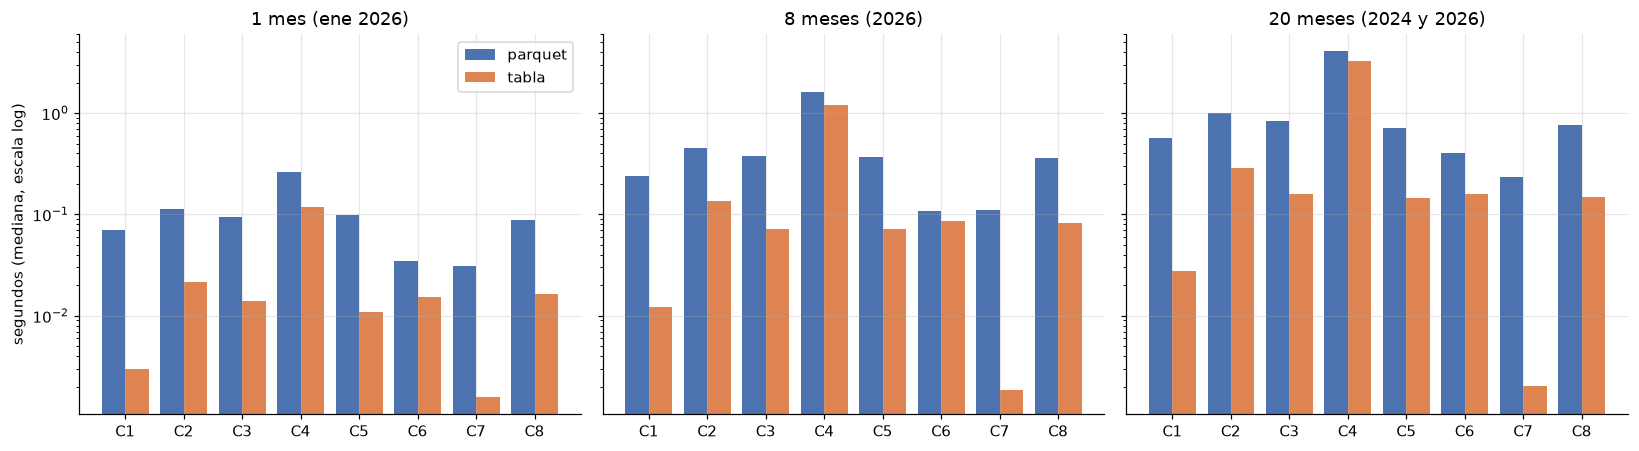

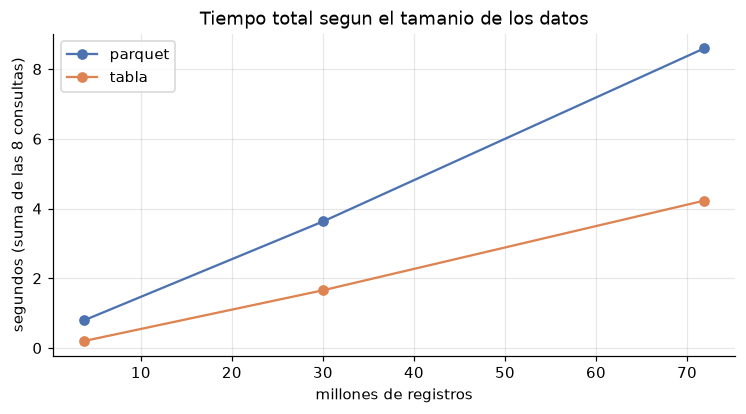

In [9]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
consultas = list(CONSULTAS)
x = np.arange(len(consultas))
for eje, escenario in zip(ejes, ESCENARIOS):
    for desplazamiento, estrategia in [(-0.2, "parquet"), (0.2, "tabla")]:
        d = resultados[(resultados.escenario == escenario) & (resultados.estrategia == estrategia)].set_index("consulta").loc[consultas]
        eje.bar(x + desplazamiento, d.mediana_s, width=0.4, color=COLORES[estrategia], label=estrategia)
    eje.set_yscale("log")
    eje.set_title(escenario)
    eje.set_xticks(x, [c.split(" ")[0] for c in consultas])
ejes[0].set_ylabel("segundos (mediana, escala log)")
ejes[0].legend()
plt.tight_layout()
plt.show()

fig, eje = plt.subplots(figsize=(8, 3.8))
for estrategia, columna in [("parquet", "suma_parquet_s"), ("tabla", "suma_tabla_s")]:
    eje.plot(resumen.registros / 1e6, resumen[columna], marker="o", color=COLORES[estrategia], label=estrategia)
eje.set_xlabel("millones de registros")
eje.set_ylabel("segundos (suma de las 8 consultas)")
eje.set_title("Tiempo total segun el tamanio de los datos")
eje.legend()
plt.show()

## Plan de ejecucion de la consulta C7 en ambas estrategias

In [10]:
for fuente in ["pq_todo", "tb_todo"]:
    plan = con.sql("EXPLAIN ANALYZE " + CONSULTAS["C7 filtro de un dia"].format(fuente=fuente)).fetchall()[0][1]
    lineas = plan.splitlines()
    total = next(l for l in lineas if "Total Time" in l).strip("│ ")
    escaneo = next(i for i, l in enumerate(lineas) if "TABLE_SCAN" in l)
    print(f"--- {fuente} | {total} ---")
    print("\n".join(lineas[escaneo - 1:]))

--- pq_todo | Total Time: 0.231s ---
┌─────────────┴─────────────┐
│         TABLE_SCAN        │
│    ────────────────────   │
│         Function:         │
│        READ_PARQUET       │
│                           │
│        Projections:       │
│          filename         │
│    tpep_pickup_datetime   │
│    lpep_pickup_datetime   │
│        total_amount       │
│                           │
│    Total Files Read: 40   │
│                           │
│        Filename(s):       │
│data/raw/*/*/*.parquet, ...│
│                           │
│                           │
│                           │
│      71,870,407 rows      │
│           1.87s           │
└───────────────────────────┘
--- tb_todo | Total Time: 0.0046s ---
┌─────────────┴─────────────┐
│         TABLE_SCAN        │
│    ────────────────────   │
│           Table:          │
│     taxis.main.tb_todo    │
│                           │
│   Type: Sequential Scan   │
│                           │
│        Projections:    

## La misma consulta C7 escrita de otras formas sobre Parquet

In [11]:
C7_YELLOW = '''
    SELECT count(*) AS viajes, avg(total_amount) AS total_promedio
    FROM {fuente}
    WHERE {filtro} >= TIMESTAMP '2026-01-15' AND {filtro} < TIMESTAMP '2026-01-16'
'''
VARIANTES = {
    "vista pq_todo, filtro sobre coalesce": C7_YELLOW.format(
        fuente="pq_todo", filtro="pickup").replace("WHERE", "WHERE tipo = 'yellow' AND"),
    "read_parquet de los 20 archivos yellow, filtro sobre la columna original": C7_YELLOW.format(
        fuente="read_parquet('data/raw/yellow/*/*.parquet', union_by_name = true)", filtro="tpep_pickup_datetime"),
    "read_parquet solo del archivo de enero 2026, filtro sobre la columna original": C7_YELLOW.format(
        fuente="read_parquet('data/raw/yellow/2026/yellow_tripdata_2026-01.parquet')", filtro="tpep_pickup_datetime"),
    "tabla tb_todo": C7_YELLOW.format(
        fuente="tb_todo", filtro="pickup").replace("WHERE", "WHERE tipo = 'yellow' AND"),
}
filas = []
for nombre, sql in VARIANTES.items():
    medir(sql)
    filas.append({"variante": nombre, "mediana_s": statistics.median(medir(sql) for _ in range(REPETICIONES)),
                  "resultado": con.sql(sql).fetchone()})
pd.DataFrame(filas).set_index("variante")

,mediana_s,resultado
variante,,
"vista pq_todo, filtro sobre coalesce",0.224,"(141194, 28.52697975834592)"
"read_parquet de los 20 archivos yellow, filtro sobre la columna original",0.079,"(141194, 28.52697975834592)"
"read_parquet solo del archivo de enero 2026, filtro sobre la columna original",0.021,"(141194, 28.52697975834592)"
tabla tb_todo,0.003,"(141194, 28.526979758345597)"


In [12]:
con.close()
print(f"Base cerrada: {BASE} ({BASE.stat().st_size / 1e9:.2f} GB)")

Base cerrada: data/processed/taxis.duckdb (3.77 GB)


## Respuestas

6.1 ¿Como se consultaron directamente los archivos Parquet?

Se crearon tres vistas, una por cada tamanio de datos, que leen los Parquet con read_parquet y dejan las columnas con los mismos nombres que se usaron en el Ejercicio 4. Una vista no guarda datos, asi que cada vez que se usa DuckDB vuelve a leer los archivos.

6.2 ¿Como se creo la tabla en DuckDB?

Se creo el archivo data/processed/taxis.duckdb y dentro de el una tabla por cada tamanio, copiando el contenido de la vista correspondiente. La tabla con los 20 meses de 2024 y 2026 tiene 71,870,407 filas y se creo en unos 10 segundos. Las tablas ocupan cerca del doble que los Parquet originales, por ejemplo 2.56 GB contra 1.23 GB en el escenario completo. Esto pasa porque Parquet comprime mas fuerte, mientras que DuckDB usa una compresion mas ligera que es mas rapida de leer, y porque la tabla guarda columnas que en la vista se calculan cada vez, como el tipo de taxi, el anio y la duracion.

6.3 ¿Que consultas se eligieron?

Se eligieron 8 consultas que salen del analisis del Ejercicio 4 y que cubren distintos tipos de trabajo. Hay un conteo simple, agrupaciones por mes y por hora, medianas, un filtro por forma de pago, una union con la tabla de zonas, un filtro de un solo dia y un conteo de valores distintos. La consulta de medianas usa solo dos medianas porque con cuatro el contenedor se quedaba sin memoria. Las medianas exactas necesitan tener todos los valores en memoria al mismo tiempo.

6.4 y 6.5 ¿Como se midieron los tiempos?

Cada consulta se corrio una vez para calentar y luego 5 veces mas, alternando entre Parquet y tabla para que ninguna tuviera ventaja por correr despues de la otra. Se guardo la mediana de las 5 ejecuciones. Antes de medir se comprobo que las dos formas dan exactamente el mismo resultado en las 24 combinaciones de consulta y tamanio, asi que la comparacion es justa.

6.6 ¿Que pasa al cambiar la cantidad de datos?

Con las dos estrategias el tiempo crece casi en linea recta con la cantidad de filas. La tabla siempre fue mas rapida, pero la diferencia relativa baja un poco cuando hay mas datos. Con un mes la tabla fue unas 4 veces mas rapida en total, y con 8 o 20 meses fue unas 2 veces mas rapida. En segundos la diferencia si crece, porque con 20 meses la tabla ahorra unos 4.4 segundos por cada ronda de las 8 consultas, contra 0.6 segundos con un mes.

6.7 y 6.8 ¿Donde estan la tabla de resultados y las consultas?

La tabla de la seccion 6.7 tiene el tiempo de cada consulta con cada estrategia y tamanio, y la cuenta de cuantas veces es mas rapida la tabla. Debajo esta el resumen por escenario con el tiempo total, el tamanio en disco y el tiempo de carga. Las 8 consultas estan escritas en la seccion 6.3 y se ejecutan igual en las dos estrategias. Lo unico que cambia es el nombre de la fuente, que es pq para la vista sobre Parquet y tb para la tabla.

6.9 ¿Por que hay diferencias?

La tabla gana porque sus datos ya estan listos para DuckDB. Con Parquet, cada consulta tiene que abrir los archivos, descomprimirlos y volver a calcular las columnas de la vista, como sacar el tipo de taxi de la ruta del archivo o juntar las dos columnas de fecha. La tabla ya tiene todo eso guardado.

La diferencia mas grande esta en el filtro de un solo dia, que fue hasta 117 veces mas rapido con la tabla. La tabla guarda el minimo y el maximo de cada bloque de filas, asi que DuckDB salta directo a los bloques de ese dia y solo lee unas 143 mil filas. En la vista sobre Parquet la fecha sale de juntar dos columnas, y por eso DuckDB no puede filtrar mientras lee y tiene que leer los casi 72 millones de filas. La ultima prueba muestra que Parquet tambien puede ser rapido si se filtra por la columna original o si se lee solo el archivo del mes. En ese caso baja de 0.22 a 0.02 segundos, aunque sigue siendo mas lento que la tabla.

El conteo simple tambien es unas 20 veces mas rapido con la tabla, porque la tabla ya sabe cuantas filas tiene. En cambio, las medianas casi no mejoran, solo 1.2 a 2 veces, porque la mayor parte del tiempo se va en ordenar los valores y eso cuesta lo mismo venga de donde venga.

La tabla tiene costos. Ocupa el doble de espacio, hay que esperar a que se cargue y no se actualiza sola cuando llegan archivos nuevos. Aun asi, el tiempo de carga se recupera rapido, porque despues de correr unas 2 o 3 veces las 8 consultas ya se ahorro lo que tomo crear la tabla.

6.10 ¿Cuando conviene cada estrategia?

Conviene consultar los Parquet directamente cuando se esta explorando los datos por primera vez o se hacen consultas de una sola vez. Tambien cuando llegan archivos nuevos seguido, porque la consulta los incluye sola sin recargar nada, y cuando hay poco espacio en disco o los mismos archivos se usan desde otras herramientas. Tambien funciona bien si las consultas filtran por anio o mes, porque se puede leer solo la carpeta o el archivo que interesa.

Conviene materializar una tabla cuando las mismas consultas se repiten muchas veces, como en un tablero de Metabase que se actualiza seguido o con varias personas consultando. Tambien cuando hay filtros por fecha o por columnas calculadas, y cuando los datos ya fueron limpiados y transformados y no se quiere repetir ese trabajo en cada consulta. Para el tablero del Ejercicio 7 conviene usar la tabla, con el cuidado de recrearla cuando se agreguen datos nuevos y de abrir la base en modo solo lectura desde Metabase.